In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import seaborn as sns

In [ ]:
df = pd.read_csv("AI_index_db.csv")
df.head()

,Country,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Region,Cluster,Income group,Political regime
0,United States of America,100.00,94.02,64.56,100.00,100.00,77.39,100.00,100.00,Americas,Power players,High,Liberal democracy
1,China,16.51,100.00,91.57,71.42,79.97,94.87,44.02,62.92,Asia-Pacific,Power players,Upper middle,Closed autocracy
2,United Kingdom,39.65,71.43,74.65,36.50,25.03,82.82,18.91,40.93,Europe,Traditional champions,High,Liberal democracy
3,Canada,31.28,77.05,93.94,30.67,25.78,100.00,14.88,40.19,Americas,Traditional champions,High,Liberal democracy
4,Israel,35.76,67.58,82.44,32.63,27.96,43.91,27.33,39.89,Middle East,Rising stars,High,Liberal democracy


In [ ]:
features_sm = [
    "Research",
    "Development",
    "Talent",
    "Infrastructure",
    "Government Strategy",
    "Commercial"
]

In [ ]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df[features_sm]),
    columns=features_sm
)

In [ ]:
weights_sm = {
    "Research": 0.30,
    "Development": 0.25,
    "Talent": 0.15,
    "Infrastructure": 0.10,
    "Government Strategy": 0.10,
    "Commercial": 0.10
}

df["Science_Medicine_Score"] = sum(
    df[col] * weight for col, weight in weights_sm.items()
)

In [ ]:
df_sorted = df.sort_values(by="Science_Medicine_Score", ascending=False)
pd.set_option('display.max_rows', None)
df_sorted[["Country", "Science_Medicine_Score"]]

,Country,Science_Medicine_Score
0,United States of America,97.1410
1,China,67.7840
6,South Korea,47.3055
5,Singapore,40.7645
2,United Kingdom,40.4710
3,Canada,39.5310
10,Australia,39.1170
8,Germany,38.1100
4,Israel,36.0250
7,The Netherlands,35.2100


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df[features_sm])

C:\Users\vemix\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vemix\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vemix\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vemix\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

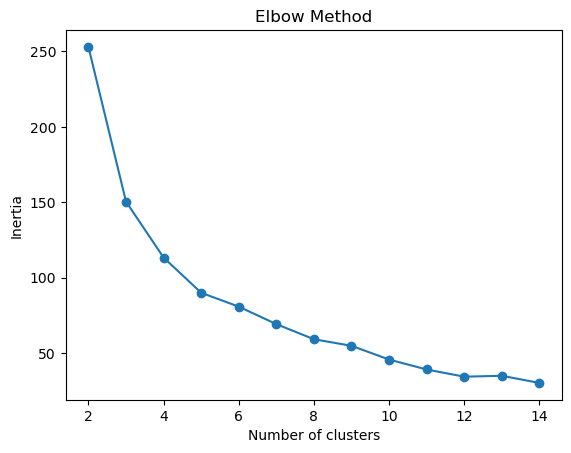

In [ ]:
X = df_scaled

inertia = []
K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

C:\Users\vemix\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vemix\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vemix\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vemix\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

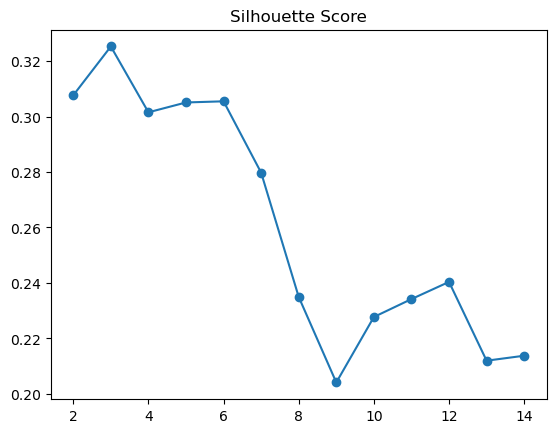

In [ ]:
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.show()

C:\Users\vemix\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vemix\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vemix\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vemix\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

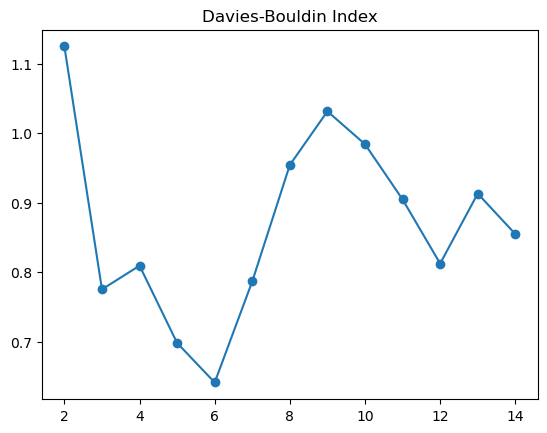

In [ ]:
db_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    db_scores.append(davies_bouldin_score(X, labels))

plt.plot(K_range, db_scores, marker='o')
plt.title("Davies-Bouldin Index")
plt.show()

C:\Users\vemix\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vemix\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vemix\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vemix\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

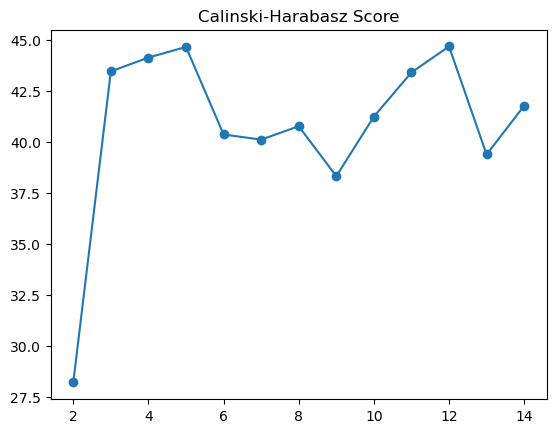

In [ ]:
ch_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    ch_scores.append(calinski_harabasz_score(X, labels))

plt.plot(K_range, ch_scores, marker='o')
plt.title("Calinski-Harabasz Score")
plt.show()

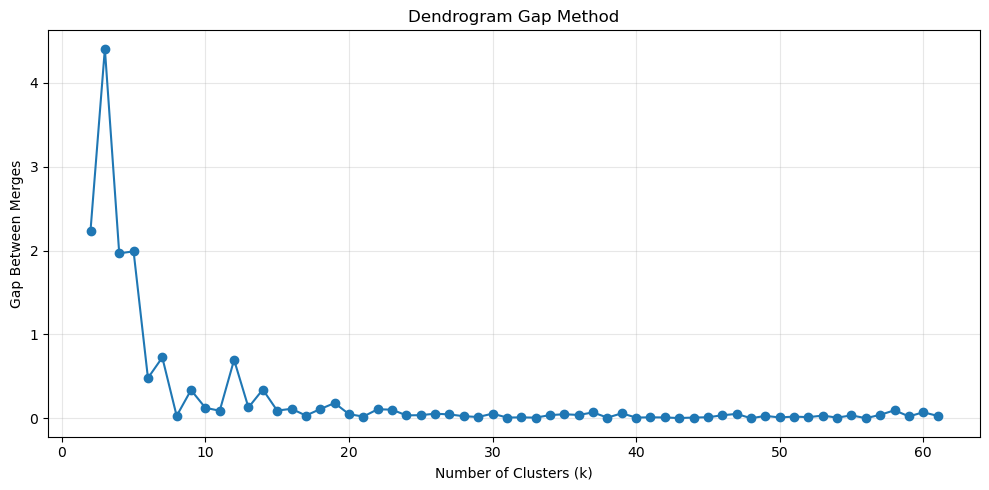

Best k from dendrogram gap method: 3
Largest gap: 4.405649645726379


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# ---------------------------------------------
# HIERARCHICAL LINKAGE
# ---------------------------------------------
Z = linkage(X, method='ward')

# Merge heights from linkage matrix
merge_heights = Z[:, 2]

# Number of observations
n = len(df)

k_values = []
gap_values = []

for i in range(len(merge_heights) - 1):
    gap = merge_heights[i + 1] - merge_heights[i]
    k = n - (i + 1)   # number of clusters before the next merge
    k_values.append(k)
    gap_values.append(gap)

k_values = np.array(k_values)
gap_values = np.array(gap_values)

# Sort by increasing k for easier reading on plot
sort_idx = np.argsort(k_values)
k_values_sorted = k_values[sort_idx]
gap_values_sorted = gap_values[sort_idx]

# Plot gap vs number of clusters
plt.figure(figsize=(10, 5))
plt.plot(k_values_sorted, gap_values_sorted, marker='o')
plt.title("Dendrogram Gap Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Gap Between Merges")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Largest gap => suggested best k
best_idx = np.argmax(gap_values_sorted)
best_k_gap = int(k_values_sorted[best_idx])
largest_gap = gap_values_sorted[best_idx]

print("Best k from dendrogram gap method:", best_k_gap)
print("Largest gap:", largest_gap)

In [ ]:
best_k_sil = K_range[np.argmax(sil_scores)]
best_k_db = K_range[np.argmin(db_scores)]
best_k_ch = K_range[np.argmax(ch_scores)]

best_k_gap_auto = int(k_values_sorted[best_idx])

print("Elbow Method best k: 6")
print("Silhouette best k:", best_k_sil)
print("DB best k:", best_k_db)
print("CH best k:", best_k_ch)
print("Dendrogram gap best k:", best_k_gap_auto)

best_k = 10

Elbow Method best k: 6
Silhouette best k: 3
DB best k: 6
CH best k: 12
Dendrogram gap best k: 3


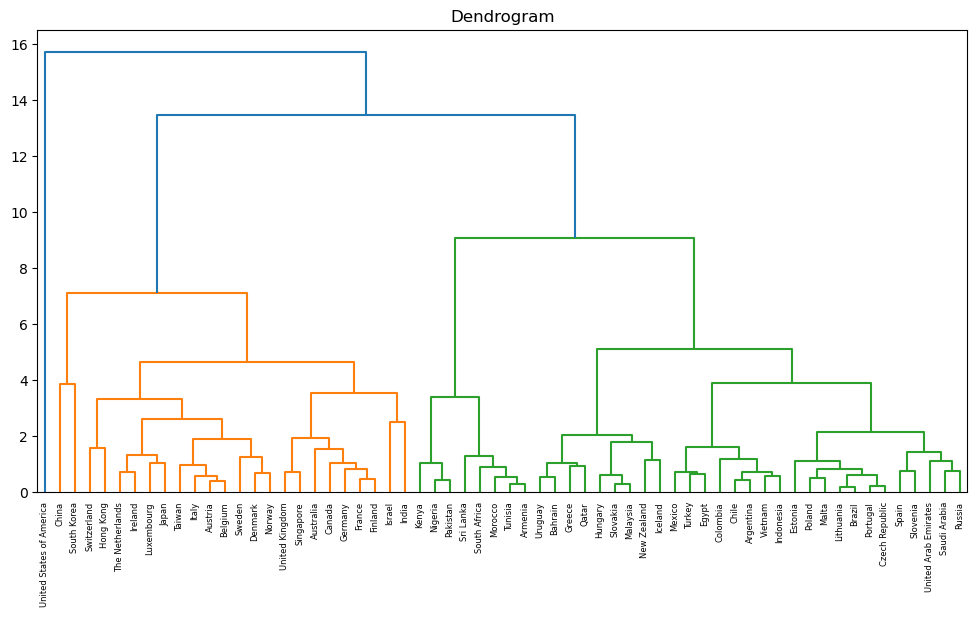

In [ ]:
Z = linkage(X, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=df["Country"].values, leaf_rotation=90)
plt.title("Dendrogram")
plt.show()

In [ ]:
df["Cluster_SM"] = fcluster(Z, best_k, criterion='maxclust')

In [ ]:
cluster_summary = df.groupby("Cluster_SM").agg({
    "Country": [list, "count"],
    "Science_Medicine_Score": "mean"
}).sort_values(by=("Science_Medicine_Score", "mean"), ascending=False)

cluster_summary

Country        \
                                                         list count   
Cluster_SM                                                            
10                                 [United States of America]     1   
1                                                     [China]     1   
2                                               [South Korea]     1   
4           [United Kingdom, Canada, Singapore, Germany, F...     7   
5                                             [Israel, India]     2   
3           [The Netherlands, Ireland, Denmark, Luxembourg...    13   
9           [Spain, Estonia, Saudi Arabia, Poland, Sloveni...    12   
7           [New Zealand, Iceland, Greece, Slovakia, Hunga...     9   
8           [Mexico, Chile, Argentina, Turkey, Colombia, V...     8   
6           [Tunisia, South Africa, Morocco, Armenia, Sri ...     8   

           Science_Medicine_Score  
                             mean  
Cluster_SM                         
10                      97.141000  
1                       67.784000  
2                       47.305500  
4                       37.851429  
5                       33.109750  
3                       29.688423  
9                       22.197833  
7                       14.543611  
8                       13.883438  
6                        6.007437

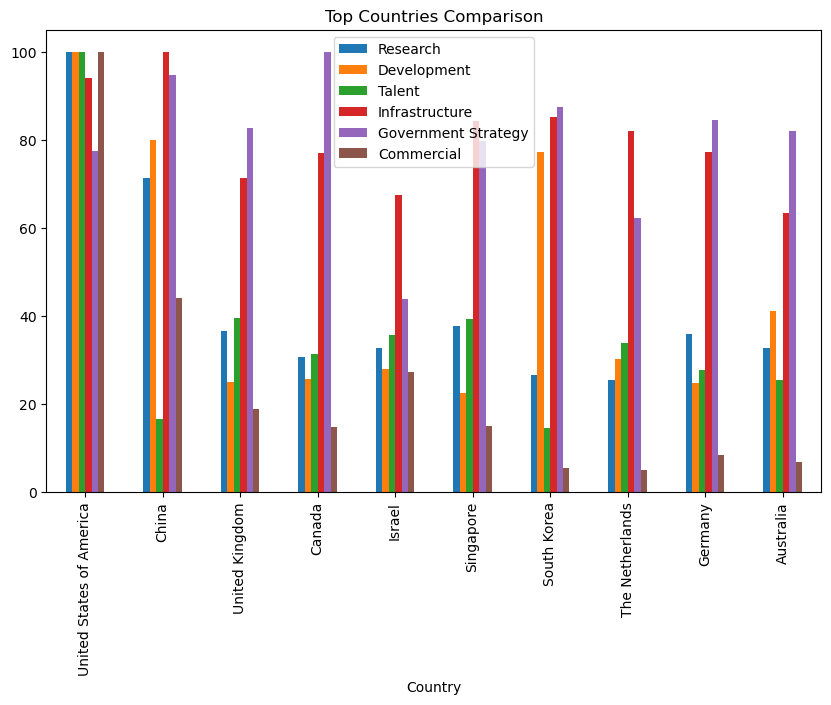

In [ ]:
top_countries = df_sorted.head(10)["Country"].values
subset = df[df["Country"].isin(top_countries)]

subset.set_index("Country")[features_sm].plot(kind="bar", figsize=(10,6))
plt.title("Top Countries Comparison")
plt.show()

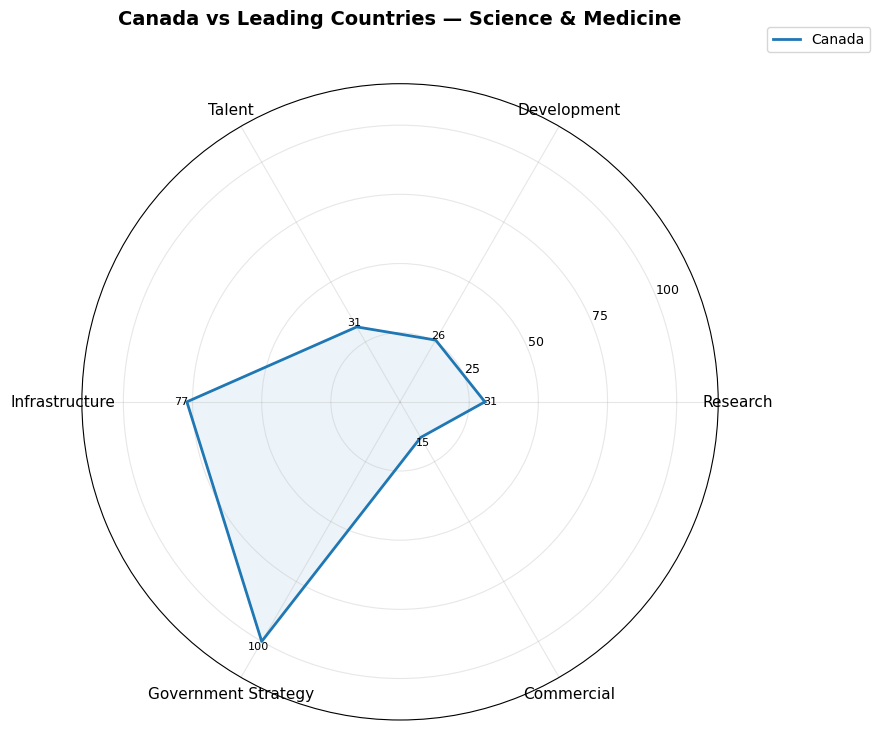

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def spider_plot(df, countries, features, title="Science & Medicine Spider Chart", fill_alpha=0.08):
    # angles for each feature axis
    angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
    angles += angles[:1]  # close the loop

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

    for country in countries:
        row = df[df["Country"] == country]

        if row.empty:
            print(f"Country not found in dataset: {country}")
            continue

        values = row[features].iloc[0].astype(float).tolist()
        values += values[:1]  # close the loop

        ax.plot(angles, values, linewidth=2, label=country)
        ax.fill(angles, values, alpha=fill_alpha)

        # optional value labels at each vertex
        for angle, value in zip(angles[:-1], values[:-1]):
            ax.text(angle, value + 2, f"{value:.0f}", ha='center', va='center', fontsize=8)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, fontsize=11)
    ax.set_title(title, y=1.08, fontsize=14, fontweight='bold')

    # radial scale
    ax.set_ylim(0, 115)
    ax.set_yticks([25, 50, 75, 100])
    ax.set_yticklabels(["25", "50", "75", "100"], fontsize=9)

    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.10))
    plt.tight_layout()
    plt.show()

    features_sm = [
    "Research",
    "Development",
    "Talent",
    "Infrastructure",
    "Government Strategy",
    "Commercial"
]

spider_plot(
    df,
    ["Canada", "United States of America", "China", "United Kingdom", "South Korea", "Singapore", "Germany"],
    features_sm,
    title="Canada vs Leading Countries — Science & Medicine"
)

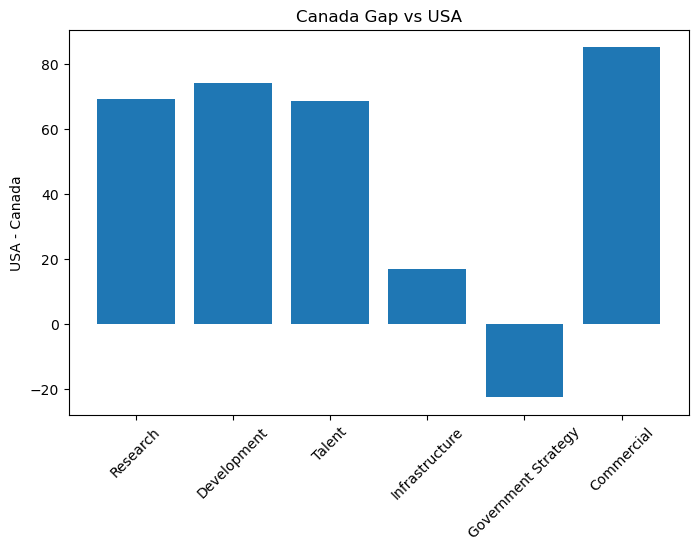

In [ ]:
canada = df[df["Country"] == "Canada"][features_sm].values.flatten()
usa = df[df["Country"] == "United States of America"][features_sm].values.flatten()

gap = usa - canada

plt.figure(figsize=(8, 5))
plt.bar(features_sm, gap)
plt.title("Canada Gap vs USA")
plt.xticks(rotation=45)
plt.ylabel("USA - Canada")
plt.show()